<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/52_DiD_NVDA_split_vs_peers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. DiD 실습: NVDA 주식분할 효과 vs 동종업계 비교
## Difference-in-Differences — Bilingual Inference Version

### 학습 목표
1. 처리군과 통제군의 개입 전·후 차이를 비교한다.
2. Difference-in-Differences(DiD)의 핵심 상호작용항을 해석한다.
3. 종목 고정효과와 날짜 고정효과를 포함한 회귀모형을 실행한다.
4. Event-style gap을 시각화한다.
5. 결과를 **영어와 한글로 모두 자동 해석**한다.

### 연구 질문
**NVDA의 10-for-1 주식분할(2024-06-10)은 AMD와 INTC 대비 거래량에 추가적 변화를 만들었는가?**

> 본 실습은 DiD 구조를 교육하기 위한 예제입니다. 실제 연구에서는 평행추세 검정, 더 넓은 통제군, 클러스터 표준오차, 동시 이벤트 통제가 필요합니다.

## 1. DiD 기본 모형

\[
Y_{it}
=
\alpha
+
\beta_1 Treated_i
+
\beta_2 Post_t
+
\beta_3(Treated_i \times Post_t)
+
\varepsilon_{it}
\]

핵심 계수는 \(\beta_3\)입니다.

- \(\beta_1\): 처리군과 통제군의 기본 차이
- \(\beta_2\): 이벤트 이후의 공통 시간 변화
- \(\beta_3\): **처리군의 추가적인 사후 변화 = DiD 효과**

## 2. 라이브러리 준비

In [1]:
# ============================================================
# STEP 1. Import libraries
# ============================================================

# Colab에서 최초 1회만 필요
# !pip install -q yfinance pandas numpy matplotlib statsmodels

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Libraries loaded successfully.")
print("라이브러리를 정상적으로 불러왔습니다.")

Libraries loaded successfully.
라이브러리를 정상적으로 불러왔습니다.


## 3. 분석 설정

- 처리군: NVDA
- 통제군: AMD, INTC
- 이벤트: NVDA 10-for-1 주식분할
- 이벤트 날짜: 2024-06-10

In [2]:
# ============================================================
# STEP 2. Analysis configuration
# ============================================================

treated_tickers = ["NVDA"]
control_tickers = ["AMD", "INTC"]
tickers = treated_tickers + control_tickers

start = "2024-02-01"
end = "2024-09-30"
event_date = pd.to_datetime("2024-06-10")

print("Treated / 처리군:", treated_tickers)
print("Controls / 통제군:", control_tickers)
print("Event date / 이벤트 일자:", event_date.date())

Treated / 처리군: ['NVDA']
Controls / 통제군: ['AMD', 'INTC']
Event date / 이벤트 일자: 2024-06-10


## 4. 데이터 수집 및 패널 구조 생성

각 종목의 가격과 거래량을 내려받은 뒤 하나의 패널 데이터로 결합합니다.

In [3]:
# ============================================================
# STEP 3. Download and combine panel data
# ============================================================

panel = []

for ticker in tickers:
    tmp = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    ).reset_index()

    # yfinance MultiIndex 대응
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = [col[0] for col in tmp.columns]

    tmp["ticker"] = ticker
    panel.append(tmp)

df = pd.concat(panel, ignore_index=True)
df["Date"] = pd.to_datetime(df["Date"])

required_cols = {"Date", "Close", "Volume", "ticker"}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Panel shape / 패널 데이터 크기:", df.shape)
display(df.head())

Panel shape / 패널 데이터 크기: (498, 7)


,Date,Close,High,Low,Open,Volume,ticker
0,2024-02-01,62.844860,63.008388,61.471841,61.920537,369146000,NVDA
1,2024-02-02,65.968811,66.407534,63.505944,63.789124,476578000,NVDA
2,2024-02-05,69.131630,69.296154,67.010778,68.027827,680078000,NVDA
3,2024-02-06,68.025833,69.552407,66.108394,69.428765,683111000,NVDA
4,2024-02-07,69.896408,70.017061,67.404630,68.121554,495575000,NVDA


## 5. DiD 변수와 결과변수 생성

- `log_volume`: 로그 거래량
- `ret`: 일별 수익률
- `treated`: NVDA이면 1
- `post`: 이벤트 이후면 1
- `did`: treated × post

In [4]:
# ============================================================
# STEP 4. Feature engineering
# ============================================================

# 로그 거래량
df["log_volume"] = np.log(df["Volume"].replace(0, np.nan))

# 종목별 일별 수익률
df["ret"] = df.groupby("ticker")["Close"].pct_change()

# 처리군 여부
df["treated"] = df["ticker"].isin(treated_tickers).astype(int)

# 이벤트 이후 여부
df["post"] = (df["Date"] >= event_date).astype(int)

# DiD 상호작용
df["did"] = df["treated"] * df["post"]

# 이벤트 상대일
df["rel_day"] = (df["Date"] - event_date).dt.days

df = df.dropna(subset=["log_volume", "ret"]).copy()

display(
    df[
        ["Date", "ticker", "Close", "Volume", "log_volume", "ret", "treated", "post", "did", "rel_day"]
    ].head(12)
)

,Date,ticker,Close,Volume,log_volume,ret,treated,post,did,rel_day
1,2024-02-02,NVDA,65.968811,476578000,19.982142,0.049709,1,0,0,-129
2,2024-02-05,NVDA,69.131630,680078000,20.337718,0.047944,1,0,0,-126
3,2024-02-06,NVDA,68.025833,683111000,20.342168,-0.015996,1,0,0,-125
4,2024-02-07,NVDA,69.896408,495575000,20.021229,0.027498,1,0,0,-124
5,2024-02-08,NVDA,69.439735,414422000,19.842395,-0.006534,1,0,0,-123
6,2024-02-09,NVDA,71.924545,436637000,19.894613,0.035784,1,0,0,-122
7,2024-02-12,NVDA,72.039200,613710000,20.235033,0.001594,1,0,0,-119
8,2024-02-13,NVDA,71.919556,602580000,20.216731,-0.001661,1,0,0,-118
9,2024-02-14,NVDA,73.686440,504917000,20.039905,0.024568,1,0,0,-117
10,2024-02-15,NVDA,72.448006,420122000,19.856056,-0.016807,1,0,0,-116


## 6. 처리군과 통제군의 개입 전후 평균 비교

DiD 회귀를 하기 전에, 먼저 2×2 평균표로 구조를 직관적으로 확인합니다.

In [5]:
# ============================================================
# STEP 5. Manual DiD calculation
# ============================================================

did_means = (
    df.groupby(["treated", "post"])["log_volume"]
      .mean()
      .unstack()
)

did_means.columns = ["Pre", "Post"]
did_means.index = ["Control", "Treated"]

did_means["Change"] = did_means["Post"] - did_means["Pre"]

manual_did = (
    did_means.loc["Treated", "Change"]
    - did_means.loc["Control", "Change"]
)

print("2x2 DiD Mean Table / 2x2 DiD 평균표")
display(did_means)

print(
    f"Manual DiD Estimate / 수기 DiD 추정치: "
    f"{manual_did:.6f}"
)

2x2 DiD Mean Table / 2x2 DiD 평균표


,Pre,Post,Change
Control,17.753838,17.798376,0.044538
Treated,20.015151,19.582185,-0.432966


Manual DiD Estimate / 수기 DiD 추정치: -0.477504


## 7. 거래량 추이 시각화

그래프는 폰트 문제를 피하기 위해 영어로 출력합니다.

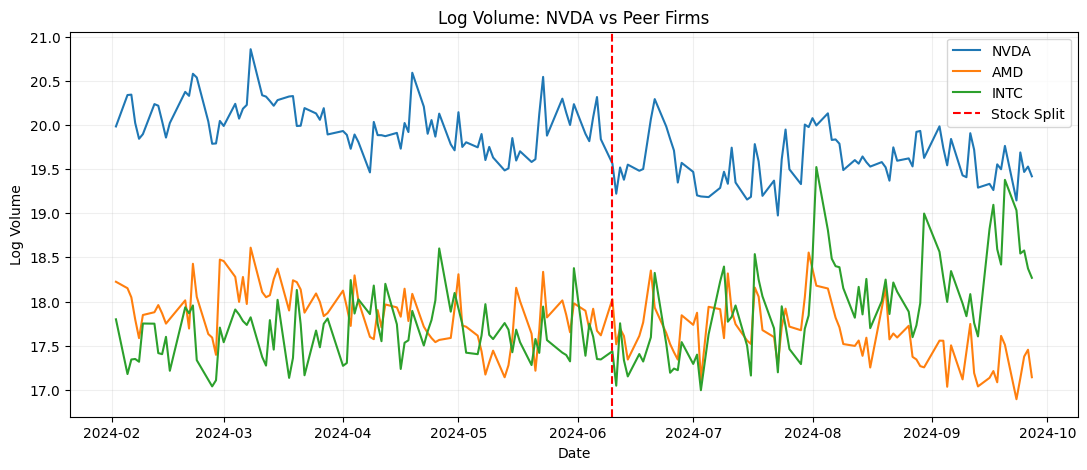

In [6]:
# ============================================================
# STEP 6. Plot log volume by ticker
# ============================================================

plt.figure(figsize=(13, 5))

for ticker in tickers:
    sub = df[df["ticker"] == ticker]
    plt.plot(
        sub["Date"],
        sub["log_volume"],
        label=ticker
    )

plt.axvline(
    event_date,
    color="red",
    linestyle="--",
    label="Stock Split"
)

plt.title("Log Volume: NVDA vs Peer Firms")
plt.xlabel("Date")
plt.ylabel("Log Volume")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. DiD 회귀모형 추정

종목 고정효과와 날짜 고정효과를 포함합니다.

- `C(ticker)`: 종목별 고정 특성 통제
- `C(Date)`: 시장 전체의 날짜별 공통 충격 통제

In [7]:
# ============================================================
# STEP 7. DiD regression
# ============================================================

model_did = smf.ols(
    "log_volume ~ treated + post + treated:post + C(ticker) + C(Date)",
    data=df
).fit(
    cov_type="HC1"
)

print(model_did.summary())

/tmp/ipykernel_1349/2833285919.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(


                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     61.75
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          3.18e-182
Time:                        08:00:43   Log-Likelihood:                -79.469
No. Observations:                 495   AIC:                             494.9
Df Residuals:                     327   BIC:                             1201.
Df Model:                         167                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 169, but rank is 167
  res = self.wald_test(


## 9. 핵심 DiD 계수 표

In [8]:
# ============================================================
# STEP 8. Compact DiD coefficient table
# ============================================================

ci = model_did.conf_int()

did_table = pd.DataFrame({
    "Coefficient": model_did.params,
    "Std. Error": model_did.bse,
    "t/z": model_did.tvalues,
    "p-value": model_did.pvalues,
    "CI Lower": ci[0],
    "CI Upper": ci[1]
}).loc[["treated", "post", "treated:post"]]

display(did_table)

,Coefficient,Std. Error,t/z,p-value,CI Lower,CI Upper
treated,1.140276,0.019133,59.597466,0.000000,1.102777,1.177776
post,-0.114573,0.168558,-0.679725,0.496679,-0.444939,0.215794
treated:post,-0.477504,0.058047,-8.226151,0.000000,-0.591275,-0.363734


## 10. Event-style gap 시각화

이벤트 전후 처리군과 통제군의 평균 로그 거래량 차이를 확인합니다.

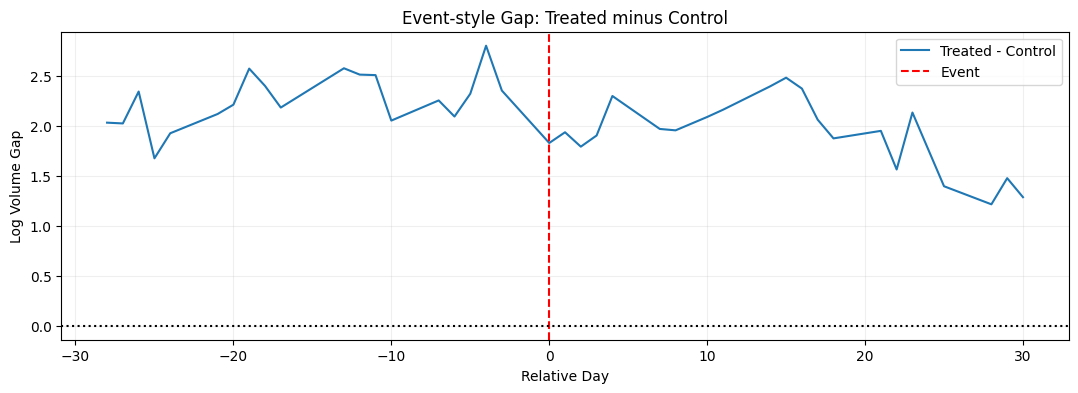

In [9]:
# ============================================================
# STEP 9. Event-style gap
# ============================================================

window = df[
    (df["rel_day"] >= -30)
    & (df["rel_day"] <= 30)
].copy()

gap = (
    window
    .groupby(["rel_day", "treated"])["log_volume"]
    .mean()
    .reset_index()
    .pivot(
        index="rel_day",
        columns="treated",
        values="log_volume"
    )
)

gap.columns = ["Control", "Treated"]
gap["Gap"] = gap["Treated"] - gap["Control"]

plt.figure(figsize=(13, 4))
plt.plot(gap.index, gap["Gap"], label="Treated - Control")
plt.axvline(0, color="red", linestyle="--", label="Event")
plt.axhline(0, color="black", linestyle=":")
plt.title("Event-style Gap: Treated minus Control")
plt.xlabel("Relative Day")
plt.ylabel("Log Volume Gap")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 11. 영어 + 한글 DiD 자동 추론 함수

`treated:post` 계수를 중심으로 효과 방향, 통계적 유의성, 95% 신뢰구간을 자동 해석합니다.

In [10]:
# ============================================================
# STEP 10. Bilingual DiD inference function
# ============================================================

def bilingual_did_inference(model, alpha=0.05):
    key = "treated:post"

    coef = model.params[key]
    p_value = model.pvalues[key]

    ci = model.conf_int(alpha=alpha)
    ci_low = ci.loc[key, 0]
    ci_high = ci.loc[key, 1]

    result = pd.DataFrame({
        "Effect": ["DiD Interaction Effect"],
        "Coefficient": [coef],
        "CI Lower": [ci_low],
        "CI Upper": [ci_high],
        "p-value": [p_value],
        "Significant (5%)": [
            "Yes" if p_value < alpha else "No"
        ]
    })

    print("=" * 90)
    print("DiD INFERENCE REPORT / DiD 추론 결과")
    print("=" * 90)

    display(result.round(6))

    print(f"Coefficient / 계수: {coef:.6f}")
    print(f"95% CI / 95% 신뢰구간: [{ci_low:.6f}, {ci_high:.6f}]")
    print(f"p-value / 유의확률: {p_value:.6f}")

    if p_value < alpha:
        if coef > 0:
            en = (
                "There is statistically significant evidence that NVDA log volume "
                "increased relative to the control firms after the stock split."
            )
            ko = (
                "주식분할 이후 NVDA의 로그 거래량이 통제기업 대비 "
                "통계적으로 유의하게 증가한 것으로 나타났습니다."
            )
        else:
            en = (
                "There is statistically significant evidence that NVDA log volume "
                "decreased relative to the control firms after the stock split."
            )
            ko = (
                "주식분할 이후 NVDA의 로그 거래량이 통제기업 대비 "
                "통계적으로 유의하게 감소한 것으로 나타났습니다."
            )
    else:
        en_dir = "positive" if coef > 0 else "negative"
        ko_dir = "양(+)" if coef > 0 else "음(-)"

        en = (
            f"The DiD effect is {en_dir}, but the statistical evidence "
            "is not strong at the 5% level."
        )
        ko = (
            f"DiD 효과는 {ko_dir} 방향이지만, "
            "5% 유의수준에서 통계적으로 유의하지 않습니다."
        )

    print("\nEnglish interpretation:")
    print(en)

    print("\n한글 해석:")
    print(ko)

    print("\nCausal Interpretation Note / 인과해석 주의")
    print(
        "EN: A causal interpretation requires the parallel trends assumption "
        "and absence of major differential confounding shocks."
    )
    print(
        "KO: 인과적으로 해석하려면 평행추세 가정이 성립하고, "
        "처리군에만 영향을 미친 주요 동시충격이 없어야 합니다."
    )

    print("=" * 90)

    return result


did_inference_table = bilingual_did_inference(model_did)

DiD INFERENCE REPORT / DiD 추론 결과


,Effect,Coefficient,CI Lower,CI Upper,p-value,Significant (5%)
0,DiD Interaction Effect,-0.477504,-0.591275,-0.363734,0.000000,Yes


Coefficient / 계수: -0.477504
95% CI / 95% 신뢰구간: [-0.591275, -0.363734]
p-value / 유의확률: 0.000000

English interpretation:
There is statistically significant evidence that NVDA log volume decreased relative to the control firms after the stock split.

한글 해석:
주식분할 이후 NVDA의 로그 거래량이 통제기업 대비 통계적으로 유의하게 감소한 것으로 나타났습니다.

Causal Interpretation Note / 인과해석 주의
EN: A causal interpretation requires the parallel trends assumption and absence of major differential confounding shocks.
KO: 인과적으로 해석하려면 평행추세 가정이 성립하고, 처리군에만 영향을 미친 주요 동시충격이 없어야 합니다.


## 12. 수익률을 결과변수로 바꾼 추가 실험

같은 DiD 구조를 수익률에도 적용하여 거래량과 가격 반응을 비교합니다.

In [11]:
# ============================================================
# STEP 11. Additional DiD experiment using returns
# ============================================================

model_ret = smf.ols(
    "ret ~ treated + post + treated:post + C(ticker) + C(Date)",
    data=df
).fit(
    cov_type="HC1"
)

print(model_ret.summary())

print("\nReturn Model Inference / 수익률 모형 추론")
_ = bilingual_did_inference(model_ret)

/tmp/ipykernel_1349/699771068.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 169, but rank is 167
  res = self.wald_test(


                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     15.11
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           6.48e-92
Time:                        08:00:46   Log-Likelihood:                 1200.5
No. Observations:                 495   AIC:                            -2065.
Df Residuals:                     327   BIC:                            -1359.
Df Model:                         167                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

,Effect,Coefficient,CI Lower,CI Upper,p-value,Significant (5%)
0,DiD Interaction Effect,-0.007853,-0.017758,0.002051,0.120178,No


Coefficient / 계수: -0.007853
95% CI / 95% 신뢰구간: [-0.017758, 0.002051]
p-value / 유의확률: 0.120178

English interpretation:
The DiD effect is negative, but the statistical evidence is not strong at the 5% level.

한글 해석:
DiD 효과는 음(-) 방향이지만, 5% 유의수준에서 통계적으로 유의하지 않습니다.

Causal Interpretation Note / 인과해석 주의
EN: A causal interpretation requires the parallel trends assumption and absence of major differential confounding shocks.
KO: 인과적으로 해석하려면 평행추세 가정이 성립하고, 처리군에만 영향을 미친 주요 동시충격이 없어야 합니다.


## 13. 최종 DiD 요약

강의에서 다음 순서로 설명하면 좋습니다.

1. 수기 2×2 DiD 평균표
2. 회귀계수 `treated:post`
3. p-value와 신뢰구간
4. Event-style gap
5. 평행추세 및 동시충격 한계